# Telco Customer Churn

#### **Context**
Predict behavior to retain customers. You can analyze all relevant customer data and develop focused customer retention programs.

**Churn**, or customer attrition, is the rate at which customers stop doing business with a company, often measured as a percentage of subscribers who cancel or don't renew over a specific time (monthly, quarterly, yearly)

**Objectives:**

- What's the % of Churn Customers and customers that keep in with the active services?
- Is there any patterns in Churn Customers based on the gender?
- Is there any patterns/preference in Churn Customers based on the type of service provided?
- What's the most profitable service types?
- Which features and services are most profitable?

#### **Content**
Each row represents a customer, each column contains customer’s attributes described on the column Metadata.

**The data set includes information about:**

- **Customers who left within the last month** – the column is called **Churn**
- **Services that each customer has signed up for** – phone, multiple lines, internet, online security, online backup, device protection, tech support, and streaming TV and movies
- **Customer account information** – how long they’ve been a customer, contract, payment method, paperless billing, monthly charges, and total charges
- **Demographic info about customers** – gender, age range, and if they have partners and dependents

## Step 1: Imports packages & dataset

In [2]:
# Import packages

# For data manipulation
import numpy as np
import pandas as pd

# For data visualization
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

# For displaying all of the columns in dataframes
pd.set_option('display.max_columns', None)

# For data modeling
from xgboost import XGBClassifier
from xgboost import XGBRegressor
from xgboost import plot_importance

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

# For metrics and helpful functions
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import roc_auc_score, roc_curve
from sklearn.tree import plot_tree

# For saving models
import pickle

In [3]:
# Download dataset from Kagglehub
import kagglehub
import os

# Download latest version
path = kagglehub.dataset_download("blastchar/telco-customer-churn")

print("Path to dataset files:", path)

/usr/local/python/3.12.1/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Path to dataset files: /home/codespace/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1


In [4]:
# Check the dataset files
all_files = os.listdir(path)
print(f"All files: {all_files}")

All files: ['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [5]:
# Load dataset into a dataframe
df0 = pd.read_csv('/home/codespace/.cache/kagglehub/datasets/blastchar/telco-customer-churn/versions/1/WA_Fn-UseC_-Telco-Customer-Churn.csv')

In [26]:
# Set up color palette
pair_palette = sns.color_palette("Paired")
qualitative_palette = sns.color_palette("Set2")

## Step 2. Initial EDA and data cleaning

#### Gather basic information about the data

In [6]:
# Display first few rows of the dataframe
df0.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [7]:
# Basic information about the data
df0.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
# Change datatype of TotalCharges to numeric type
df0['TotalCharges'] = pd.to_numeric(df0['TotalCharges'], errors='coerce')

#### Gather descriptive statistics about the data

In [9]:
df0.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7032.000000
mean,0.162147,32.371149,64.761692,2283.300441
std,0.368612,24.559481,30.090047,2266.771362
min,0.000000,0.000000,18.250000,18.800000
25%,0.000000,9.000000,35.500000,401.450000
50%,0.000000,29.000000,70.350000,1397.475000
75%,0.000000,55.000000,89.850000,3794.737500
max,1.000000,72.000000,118.750000,8684.800000


#### Rename columns

In [10]:
# Rename columns 
df0 = df0.rename(columns = {'customerID' : 'CustomerID',
                            'gender': 'Gender',
                            'tenure': 'Tenure'})

In [11]:
# Display all column names after the update
df0.columns

Index(['CustomerID', 'Gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'Tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

#### Check missing value

In [12]:
# Check missing value 
df0.isna().sum()

CustomerID           0
Gender               0
SeniorCitizen        0
Partner              0
Dependents           0
Tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

There are 11 missing values in the TotalCharges column

In [13]:
# Inspect rows containing missing values
df0[np.isnan(df0['TotalCharges'])]

,CustomerID,Gender,SeniorCitizen,Partner,Dependents,Tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,4472-LVYGI,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,3115-CZMZD,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,5709-LVOEQ,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,4367-NUYAO,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,1371-DWPAZ,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,7644-OMVMY,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,3213-VVOLG,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,2520-SGTTA,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,2923-ARZLG,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,4075-WKNIU,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


Tenure column is 0 for these entries. We can normally drop these rows.

In [14]:
# Drop missing values in TotalCharges column
df0 = df0.dropna(subset = 'TotalCharges')

#### Check duplicates

In [15]:
df0['CustomerID'].duplicated().sum()

np.int64(0)

There are no duplicates values in the data.

#### Check outliers

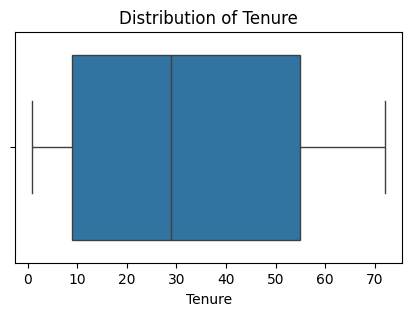

In [16]:
# Create a boxplot to visualize distribution of 'Tenure' and detect any outliers
plt.figure(figsize = (5,3))
plt.title('Distribution of Tenure')
sns.boxplot(x=df0['Tenure'])
plt.show()

There is so outliers in Tenure

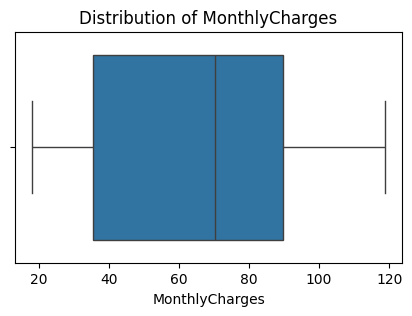

In [17]:
# Create a box plot to visualize distribution of MonthlyCharges and detect any outliers
plt.figure(figsize = (5,3))
plt.title('Distribution of MonthlyCharges')
sns.boxplot(x=df0['MonthlyCharges'])
plt.show()

There is no outliers in Monthly Charges

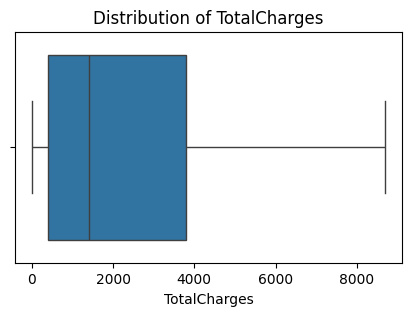

In [18]:
# Create a box plot to visualize distribution of TotalCharges and detect any outliers
plt.figure(figsize = (5,3))
plt.title('Distribution of TotalCharges')
sns.boxplot(x=df0['TotalCharges'])
plt.show()

## Step 3: Continue EDA & Visualizations

#### Churn Rate by Tenure

In [20]:
df1 = df0.copy()

In [56]:
# Group Tenure by range
bins = [0, 12, 24, 48, 72]
labels = ['0-12', '13-24', '25-48', '49+']

df1['tenure_group'] = pd.cut(
    df0['Tenure'],
    bins=bins,
    labels=labels,
    include_lowest=True
)

In [58]:
# Function to create charts

def bar_chart_churn_rate(df, variable):

    # Calculate churn rate by group
    churn_rate = (
        df
        .groupby([variable, 'Churn'], observed=True)
        .size()
        .unstack(fill_value=0)
        .reset_index()
    )
    
    churn_rate['churn_rate'] = churn_rate['Yes'] / (churn_rate['Yes'] + churn_rate['No'])

    # Set up subplots: 1 row, 2 columns
    fig, axes = plt.subplots(1, 2, figsize=(10,3))

    # Bar chart for Churn Rate
    axes[0].bar(churn_rate[variable], churn_rate['churn_rate'], color = pair_palette[0])
    axes[0].set_xlabel(variable)
    axes[0].set_ylabel('Churn Rate')
    axes[0].set_title(f'Churn Rate by {variable}')
    axes[0].yaxis.set_major_formatter(PercentFormatter(1))
    plt.setp(axes[0].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Bar chart for Distribution (count)
    total_count = churn_rate['Yes'] + churn_rate['No']
    axes[1].bar(churn_rate[variable], total_count, color = pair_palette[1])
    axes[1].set_xlabel(variable)
    axes[1].set_ylabel('Number of Customers')
    axes[1].set_title(f'Distribution of {variable}')
    plt.setp(axes[1].xaxis.get_majorticklabels(), rotation=30, ha='right')

    # Adjust the width space between the subplots
    plt.subplots_adjust(wspace=0.5)

    plt.show()

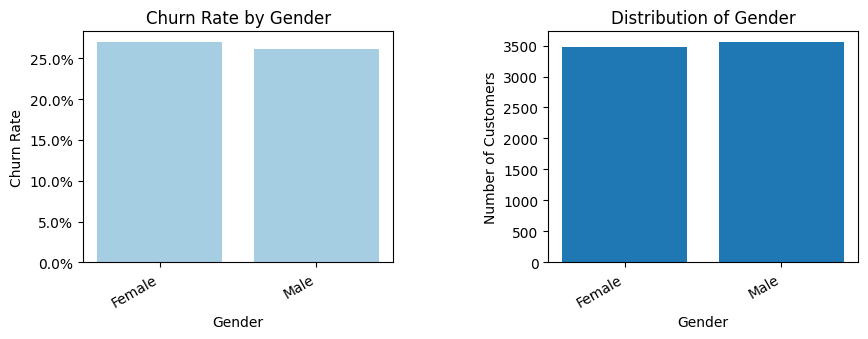

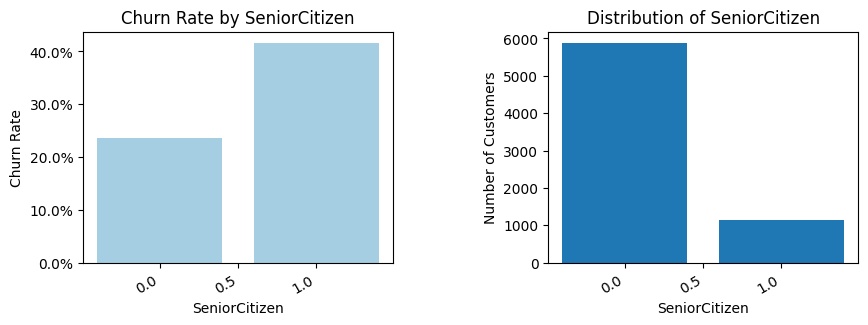

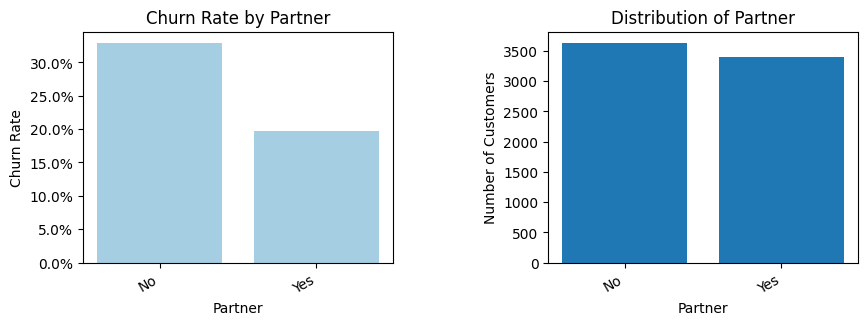

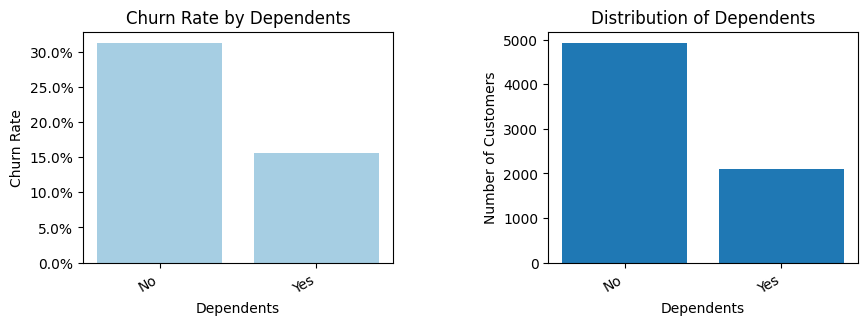

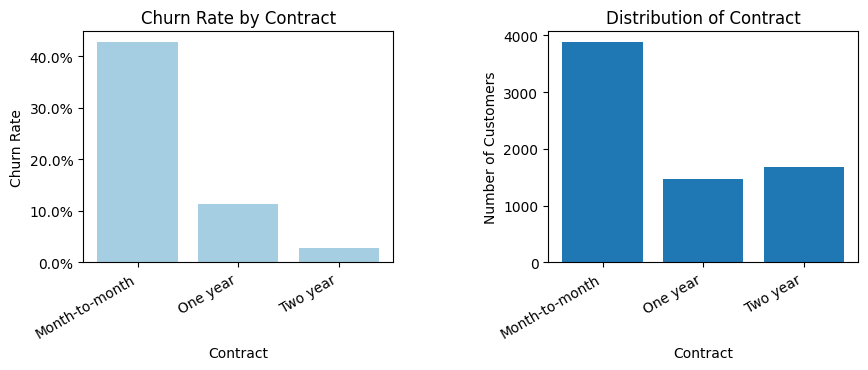

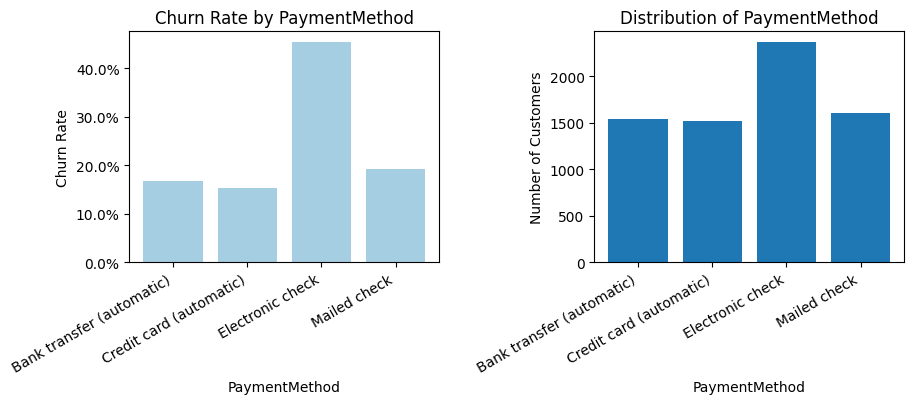

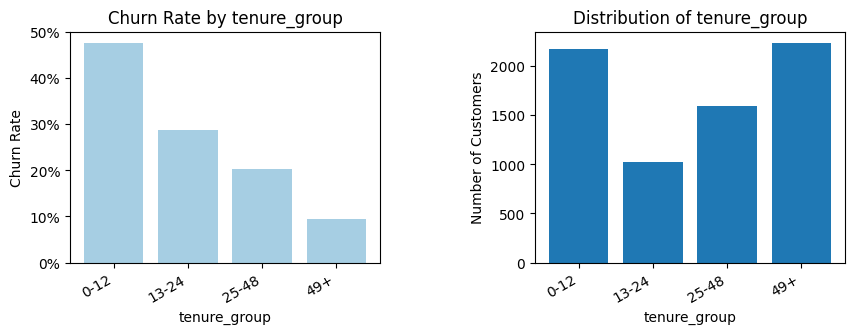

In [59]:
# Column to visualize with bar chart 
col_to_visualize = ['Gender', 'SeniorCitizen', 'Partner', 'Dependents', 'Contract', 'PaymentMethod', 'tenure_group']

for col in col_to_visualize:
    visualize_churn_rate(df1,col)

#### Some insights

**Gender**
- Distribution: Relatively balanced (`~50-50%`) between Female and Male customers
- Churn rate: Nearly identical (`~26-27%`) for both groups

**SeniorCitizen (Age Group)**
- Senior citizens account for only `~16%` of total customers
- Churn rate for seniors `~41%` is approximately `1.7x` higher than non-seniors (`~24%`)

**Partners**
- Distribution: Relatively balanced between customers who have partners and who do not
- Customers without partners have higher churn rate

**Dependents (Family Structure)**
- `~70%` of customers do NOT have dependents
- Customers WITHOUT dependents have `2x` higher churn rate (`~31%` vs `~16%`)

<span style='color:#FF0000'>**Contract (Contract Type)**</span>
- Month-to-month contracts dominate (`~55%` of customers)
- Churn rate decreases dramatically with contract length: `~43%` (MTM) → `~11%` (One year) → `~3%` (Two year)

**Payment Method**
- Electronic check is the most common payment method, while Bank transfer, Credit card and Mailed check are roughly the same
- Electronic check customers also have the highest churn rate, approximately `45%`, while other methods remain lower than `20%`

<span style='color:#FF0000'>**Tenure**</span>
- Customers are concentrated at two extremes: new customers (0-12 months) account for `~32%` and long-term customers (49+ months) represent `~33%` of the customer base
- Mid-tenure customers (13-24 months and 25-48 months) each comprise approximately `15-23%` of customers
- Clear inverse relationship between tenure and churn rate
- New customers (0-12 months): `~48%` churn rate - critically high
- 13-24 months: `~29%` churn rate
- 25-48 months: `~21%` churn rate
- Long-term customers (49+ months): `~10%` churn rate - lowest risk group

**MonthlyCharges**
- Churned customers: Concentrated in `$70-$110` range (high-cost plans)
- Retained customers: Broader distribution with significant presence in `$20-$40` range (low to mid-tier plans)
- No Churn: Median `~$65`, range `$20-$110`, relatively symmetric distribution
- Yes Churn: Median `~$80`, concentrated in `$70-$100` range, shifted significantly higher

**TotalCharges**
- Direct correlation: **TotalCharges = Tenure × MonthlyCharges**
- Churned customers: Heavily concentrated at `$0-$2,000` (low lifetime value)
- Retained customers: Wide distribution extending to `$8,000`, showing sustained customer relationships
- No Churn: Median `~$1,400`, maximum `$8,700`, few outliers
- Yes Churn: Median `~$500`, maximum `$8,000`, multiple high-value outliers present

#### Churn vs Non-Churn with Numeric variables

In [67]:
# Column with numeric variable to visualize
numerical_cols = ['Tenure', 'MonthlyCharges', 'TotalCharges']

In [77]:
# Function to create histogram, boxplot and density plot for numeric variables
def plot_numerical_analysis(df, col):
    fig, axes = plt.subplots(1, 3, figsize=(15, 4))
    
    # Histogram by Churn
    axes[0].hist([df[df['Churn']=='No'][col], df[df['Churn']=='Yes'][col]], 
                 label=['No Churn', 'Churn'], bins=30, alpha=0.7)
    axes[0].set_xlabel(col)
    axes[0].set_ylabel('Frequency')
    axes[0].set_title(f'Distribution of {col} by Churn')
    axes[0].legend()
    
    # Boxplot
    df.boxplot(column=col, by='Churn', ax=axes[1])
    axes[1].set_title(f'{col} by Churn')
    axes[1].set_xlabel('Churn')
    plt.suptitle('')
    
    # Density plot
    df[df['Churn']=='No'][col].plot(kind='density', ax=axes[2], label='No Churn')
    df[df['Churn']=='Yes'][col].plot(kind='density', ax=axes[2], label='Churn')
    axes[2].set_title(f'Density Plot of {col}')
    axes[2].legend()
    
    plt.tight_layout()
    plt.show()

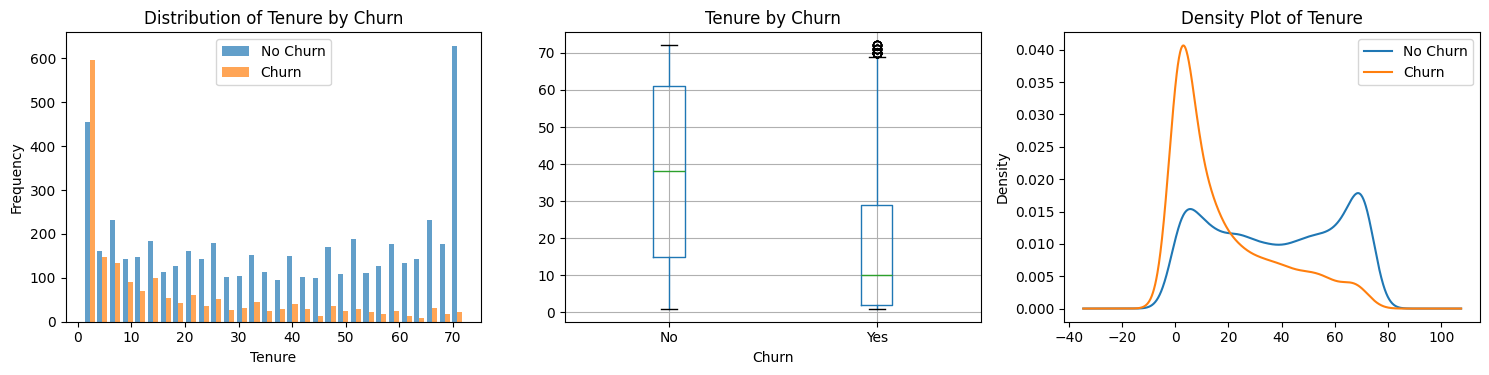

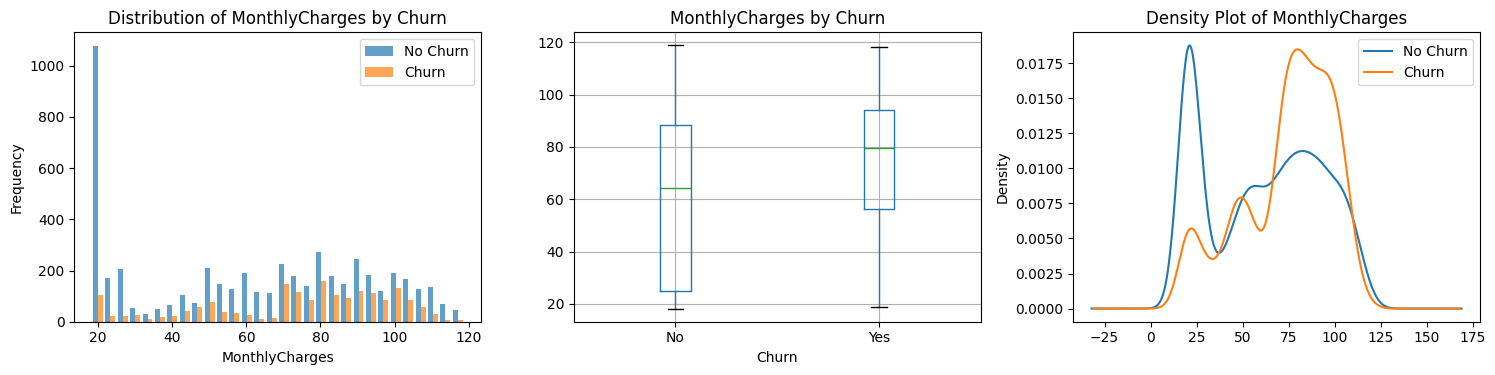

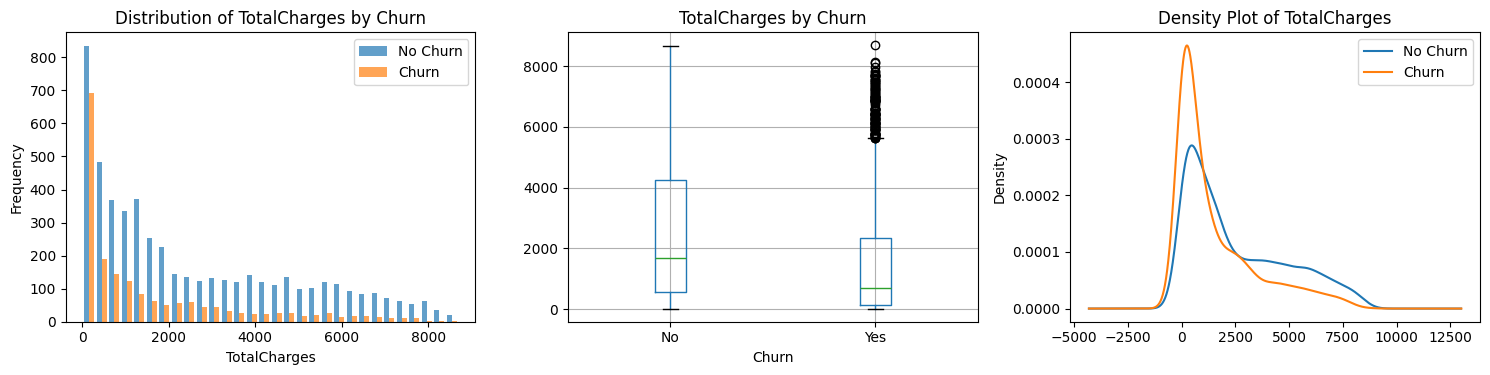

In [78]:
# Create chart
for col in numerical_cols:
    plot_numerical_analysis(df1, col)

##### Some insights

**MonthlyCharges**

- Churned customers (orange): Concentrated in `$70-$110` range (high-cost plans)
- Retained customers (blue): Broader distribution with significant presence in `$20-$40` range (low to mid-tier plans)
- No Churn: Median `~$65`, range `$20-$110`, relatively symmetric distribution
- Yes Churn: Median `~$80`, concentrated in `$70-$100` range, shifted significantly higher

**TotalCharges**

- Direct correlation: **TotalCharges = Tenure × MonthlyCharges**
- Churned customers (orange): Heavily concentrated at `$0-$2,000` (low lifetime value)
- Retained customers (blue): Wide distribution extending to `$8,000`, showing sustained customer relationships
- No Churn: Median `~$1,400`, maximum `$8,700`, few outliers
- Yes Churn: Median `~$500`, maximum `$8,000`, multiple high-value outliers present